In [ ]:
import pandas as pd
import cv2 as cv2
import cv2.aruco as aruco
import pickle
import numpy as np
import datetime as dt
from Cmanage import c_manage
from Calibrate import calibrate
from scipy.spatial.transform import Rotation as R
import json
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


Loading folder with all videos as c_manage object

In [ ]:
sim = c_manage(cam_direct=r"C:\Users\franc\Documents\Infant_Sim_data\passive sim\Cameras", vid_name="sim_trunk")
calib_stats1, calib_names1 = sim.check_vids(1)
sim.intrinsics_orientation(calib_names1, calib_stats1)
calib_stats3, calib_names3 = sim.check_vids(3)


Camera:  1
270
Camera:  2
180
Camera:  3
180
Camera:  4
180
Camera:  5
180
Camera:  6
0
Camera:  7
0


Getting tag poses based on camera number (camnum)

In [ ]:
camnum=3
tag_pose=pd.DataFrame() 

cap = cv2.VideoCapture(calib_names3[camnum-1])

intrinsics=sim.intrinsics_final["cam"+str(camnum)]

view=0

framenum=0
max_frames=cap.get(cv2.CAP_PROP_FRAME_COUNT)
print(max_frames)

# # Check if camera opened successfully
if (calib_stats3[camnum-1]==0):
    print("No Video") 
elif (cap.isOpened()== False):
    print("Error opening video file")

else:
    # Read until video is completed
    while(cap.isOpened() and framenum<max_frames):
        
    # Capture frame-by-frame
        ret, frame = cap.read()
        if ret == True:
        # Display the resulting frame
            
            frame,ids,tvecs, rvecs=apriltag_pose(frame,intrinsics)
            framenum=int(cap.get(cv2.CAP_PROP_POS_FRAMES))

            row0 = pd.DataFrame({'ID':[ids[0,0]],'tvec':[tvecs[:,0]], 'rvecs':[rvecs[:,0]], 'frame':[framenum]})
            row25 = pd.DataFrame({'ID':[ids[1,0]],'tvec':[tvecs[:,1]], 'rvecs':[rvecs[:,1]], 'frame':[framenum]})

            tag_pose = pd.concat([tag_pose, row0], ignore_index=True)
            tag_pose = pd.concat([tag_pose, row25], ignore_index=True)

            print(framenum)
            if view==1:
                cv2.namedWindow("Frame", cv2.WINDOW_NORMAL)
                cv2.imshow('Frame', frame)

                if cv2.waitKey(25) & 0xFF == ord('q'):
                    break
            

    
    cap.release()

    # Closes all the frames
    cv2.destroyAllWindows()

    print(tag_pose)

2375.0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
2

Saving tag poses as json with specifc name

In [ ]:

name='cam3_vid3_tagpose.json'
tag_pose.to_json(name,orient="split")


Pulling saved tag poses json with specifc name

In [4]:
name='cam3_vid3_tagpose.json'
tag_pose=(pd.read_json(name, orient='split'))

Function that gets april tag poses for image, given intrinsics

In [ ]:
def apriltag_pose(frame,intrinsics):
    ARUCO_PARAMETERS = aruco.DetectorParameters()
    ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_APRILTAG_36h11)



    ProjectImage=frame

    # grayscale image
    gray = cv2.cvtColor(ProjectImage, cv2.COLOR_BGR2GRAY)

    cameraMatrix=intrinsics['Mat']
    distCoeffs=intrinsics['Dist']

    # Detect Aruco markers
    detector = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMETERS)
    # marker_corners, marker_ids, rejected_candidates = detector.detectMarkers(image)
    corners, ids, rejectedImgPoints = detector.detectMarkers(gray)
    

    # Outline all of the markers detected in our image
    # Uncomment below to show ids as well
    # ProjectImage = aruco.drawDetectedMarkers(ProjectImage, corners, borderColor=(0, 0, 255))
    markerlength=50/1000

    rvecs=np.zeros((3,len(ids)))
    tvecs=np.zeros((3,len(ids)))
    tot_error=0

    for j in range(len(ids)):
        corner=corners[j]
        id=ids[j]
        
        # rvec,tvec,objpts=aruco.estimatePoseSingleMarkers(corner, markerlength, cameraMatrix, distCoeffs)
        objpts = np.array([[-markerlength / 2, markerlength / 2, 0],
                              [markerlength / 2, markerlength / 2, 0],
                              [markerlength / 2, -markerlength / 2, 0],
                              [-markerlength / 2, -markerlength / 2, 0]], dtype=np.float32)
        success,rvec,tvec=cv2.solvePnP(objpts, np.reshape(corner,(4,1,2)), cameraMatrix, distCoeffs)
    
        # print('Camera ',i, success, len(ids))

        tvecs[:,[j]]=tvec
        rvecs[:,[j]]=rvec
        

        imgpts_rpj, _ = cv2.projectPoints(objpts, rvec, tvec, cameraMatrix, distCoeffs)
        # print(imgpts_rpj)

        # ProjectImage = aruco.drawDetectedMarkers(ProjectImage, imgpts.reshape(-1, 2), borderColor=(0, 0, 255))

        # print(corner[0,:,:].shape, imgpts_rpj[:,0,:].shape)
        error = cv2.norm(corner[0,:,:], imgpts_rpj[:,0,:], cv2.NORM_L2)/len(imgpts_rpj[:,0,:])
        tot_error=tot_error+error

        length_of_axis = 0.05
        ProjectImage = cv2.drawFrameAxes(ProjectImage, cameraMatrix, distCoeffs, rvec, tvec, length_of_axis)
        
        # print( "total error: {}".format(error/len(imgpts)) )
        
    
        for point in imgpts_rpj.astype(int): 
            ProjectImage = cv2.circle(ProjectImage, tuple(point[0]), 2, 255, -1) 
    
    # print( "total error: {}".format(tot_error/len(ids)) )

    # cv2.imshow("ProjectImage", ProjectImage)
    return ProjectImage,ids,tvecs, rvecs

Getting global intrinsics from calibration video

In [ ]:
camnum=3

intrinsics=sim.intrinsics_final["cam"+str(camnum)]
calib_vid=calib_names1[camnum-1]

calib=calibrate(video=calib_vid,vid_intrinsic=intrinsics)

img=calib.pull_frames_static(calib_vid)
cam_ex,rerror=calib.calibrate_extrinsics(img, intrinsics, view=1)

exiting


Correcting global extrinsic matrix (X,-Y,-Z)

In [21]:
rvec_glob=cam_ex['Rvec']
tvec_glob=cam_ex['Tvec']

R_glob = R.from_rotvec(rvec_glob.T)
# print(R_glob)

R_orient=R.from_matrix(np.matrix([[1,0,0],[0,-1,0],[0,0,-1]]))
# print(R_orient)

R_glob_cor=R_glob*R_orient
print(R_glob_cor)

# for i in range()

Rotation.from_matrix(array([[[   -0.99957,   -0.029098,  -0.0041526],
                             [  -0.029318,     0.99709,    0.070387],
                             [  0.0020924,    0.070479,    -0.99751]]]))


In [ ]:
tag0=tag_pose.loc[(tag_pose["ID"]==0)]
tag25=tag_pose.loc[(tag_pose["ID"]==25)]

max_frames=(np.max(tag25["frame"]))

rv0=tag0['rvecs']
tv0=tag0['tvec']

rv25=tag25['rvecs']
tv25=tag25['tvec']

rv0=R.from_rotvec(np.array(rv0.to_list()))
tv0=(np.array(tv0.to_list()))
rv25=R.from_rotvec(np.array(rv25.to_list()))
tv25=(np.array(tv25.to_list()))


rv0_glob=(R_glob_cor*rv0.inv())
# tv0_glob=(rv0_glob*tv0)
rv25_glob=(R_glob_cor*rv25.inv())
print(rv25_glob.as_euler('xzy', degrees=True))

tv0_glob=tvec_glob.T-tv0
tv25_glob=tvec_glob.T-tv25

# for rv in tag25.rvecs:


[[    -172.93      2.7146      179.01]
 [    -173.49       3.191      179.97]
 [    -172.93      2.7146      179.01]
 ...
 [     172.67      3.9115     -179.96]
 [     172.67      3.9115     -179.96]
 [     172.88       3.563      178.02]]


In [155]:
print(tv0_glob[0])

[    0.12564    0.065307   -0.064382]


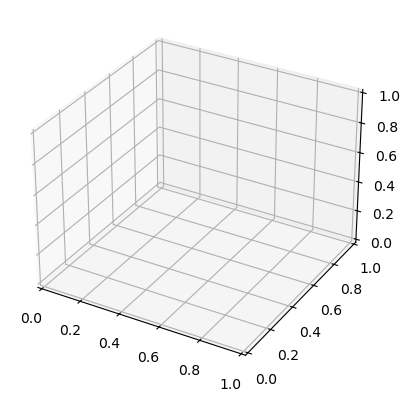

: 

In [ ]:


# def showtags(j,tv0,rv0,tv25,rv25):
def showtags(j):
    plt.cla()
    # tv_0=tv0[:,j]
    # rv_0=rv0[:,j]
    # tv_25=tv25[:,j]
    # rv_25=rv25[:,j]
    # print(tv0_glob[int(j)])
    # print(type(j))


    tv_0=tv0_glob[j]
    rv_0=rv0_glob[j]
    tv_25=tv25_glob[j]
    rv_25=rv25_glob[j]

    
    # print(tv_0[0], tv_0[1], tv_0[2])
    # print(1)
    # ax.plot3D(tv_0[0], tv_0[1], tv_0[2],'o', 'green')
    # print(2)
    ax.plot3D([tv_0[0], tv_25[0]],
                [tv_0[1],  tv_25[1]],
                [tv_0[2],  tv_25[2]],'o')
    # print(3)

    # if show_Ik == True:
    #     self.show_T(j)
    # if show_model == True:
    #     self.model_overlay(j)

    
    # self.ax.text(0.3, -0.4, 0, "%s" % (s2), size=20, zorder=1, color="k")

    # # plt.text(0, 0, s)
    ax.set_zlim3d(0, 0.6)
    ax.set_ylim3d(-0.4, 0.2)
    ax.set_xlim3d(-0.3, 0.3)
    # print(4.5)
    plt.grid()
    # print(4)

    

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# print(np.linspace(1,max_frames,max_frames))

# ani = FuncAnimation(fig, showtags, interval=1, frames=np.linspace(1,max_frames,max_frames), fargs=(tv0_glob,rv0_glob,tv25_glob,rv25_glob))
ani = FuncAnimation(fig, showtags, frames=np.linspace(1,max_frames,max_frames,dtype=int))
plt.show()
    

# showtags_loop()

def show_Ti(ax, tvec, rvec, scale=0.1, sign=1):

    dx, dy, dz = tvec[0,0], tvec[0,1], tvec[0,2]

    var = 1 * scale * sign

    xaxis = np.matrix([[var], [0], [0], [1]])
    yaxis = np.matrix([[0], [var], [0], [1]])
    zaxis = np.matrix([[0], [0], [var], [1]])

    Ri = Ti[0:3, 0:3]

    x = Ri @ xaxis[0:3, 0]
    y = Ri @ yaxis[0:3, 0]
    z = Ri @ zaxis[0:3, 0]

    # print("B4: ", xaxis * 1000)
    # print("AF: ", x * 1000)
    # print(x[1, 0])
    # print(x[2] ** 2 + x[1] ** 2)

    d = scale / 10

    ax.quiver([dx], [dy], [dz], x[0, 0], x[1, 0], x[2, 0], colors=[1, 0, 0])
    ax.text(
        x[0, 0] + dx + d * 1,
        x[1, 0] + dy + d * 1,
        x[2, 0] + dz + d * 1,
        "X" + str(i),
        size=10,
        zorder=1,
        color=[1, 0, 0],
    )

    ax.quiver([dx], [dy], [dz], y[0, 0], y[1, 0], y[2, 0], colors="green")
    ax.text(
        y[0, 0] + dx + d * 2,
        y[1, 0] + dy + d * 2,
        y[2, 0] + dz + d * 2,
        "Y" + str(i),
        size=10,
        zorder=1,
        color="green",
    )

    ax.quiver([dx], [dy], [dz], z[0, 0], z[1, 0], z[2, 0], colors=[0, 0, 1])
    ax.text(
        z[0, 0] + dx + d * 3,
        z[1, 0] + dy + d * 3,
        z[2, 0] + dz + d * 3,
        "Z" + str(i),
        size=10,
        zorder=1,
        color=[0, 0, 1],
    )

    return ax